In [2]:
from focalcodec.codec import FocalCodec
from pathlib import Path
import torch
import soundfile as sf
import torchaudio
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from IPython import display
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar
import gc
import io
import json
from phonemizer import phonemize
from phonemizer.separator import Separator

DATA = Path("data")
LJSPEECH = DATA / "LJSpeech-1.1"
PONY = DATA / "pony-speech"
LLM = DATA / "llm"
IMG = Path("img")

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device


'cuda'

In [3]:
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz')
codec.to(device)
codec.eval()

for p in codec.parameters():
  p.requires_grad_(False)


In [4]:
CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input

print(f'codebook={CODEBOOK_SIZE}, sr_in/out={CODEC_SR}/{codec.sample_rate_output}')


codebook=8192, sr_in/out=16000/16000


In [5]:
def load_wav_16k(path):
  arr, sr = sf.read(path, dtype='float32', always_2d=False)

  if arr.ndim > 1:
    arr = arr.mean(-1)

  wav = torch.from_numpy(arr)

  if sr != CODEC_SR:
    wav = torchaudio.functional.resample(wav, sr, CODEC_SR)

  return wav

def plot_mel(wav, sr, title=''):
  wav = np.asarray(wav).astype(np.float32)

  if wav.ndim > 1:
    wav = wav.mean(0)

  S = librosa.feature.melspectrogram(
    y=wav, sr=sr, n_fft=1024, hop_length=256,
    n_mels=80, fmin=50, fmax=sr//2
  )

  _, ax = plt.subplots(figsize=(max(6, len(wav)/sr*1.2), 3))

  librosa.display.specshow(
    librosa.power_to_db(S, ref=np.max),
    sr=sr, hop_length=256,
    x_axis='time', y_axis='mel',
    ax=ax
  )
  ax.set_title(title, fontsize=9)
  plt.show()


In [6]:
train = pd.read_parquet(LJSPEECH / "train.parquet")
test = pd.read_parquet(LJSPEECH / "test.parquet")
val = pd.read_parquet(LJSPEECH / "val.parquet")


file                                                      LJ032-0164
text               it is not possible to state with scientific ce...
normalized_text    it is not possible to state with scientific ce...
path                           data/LJSpeech-1.1/wavs/LJ032-0164.wav
phon               ɪ ɾ | ɪ z | n ˌɑː t | p ˈɑː s ᵻ b əl | t ə | s...
Name: 8641, dtype: str
LJ032-0164: 7.43s -> 186 tokens


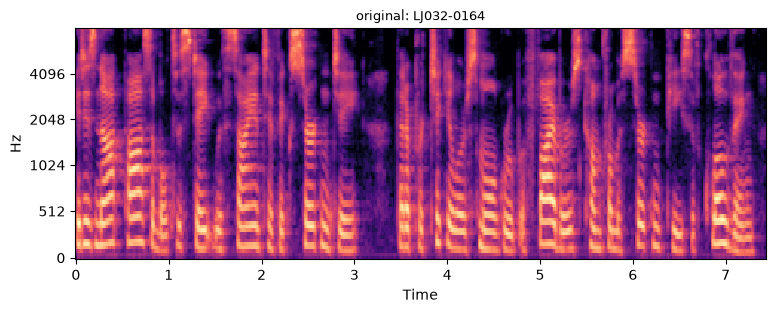

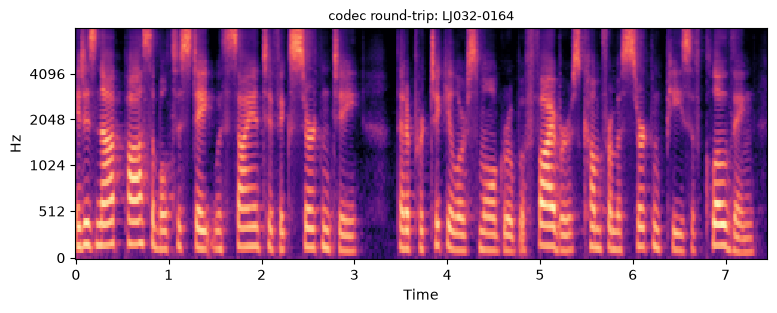

In [7]:
row = val.iloc[0]
print(row)
wav = load_wav_16k(row['path']).to(device)

with torch.no_grad():
  toks = codec.sig_to_toks(wav.unsqueeze(0))
  rec = codec.toks_to_sig(toks).squeeze(0).detach().cpu().numpy()

print(f'{row["file"]}: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens')
plot_mel(wav.cpu().numpy(), CODEC_SR, f'original: {row["file"]}')
plot_mel(rec, codec.sample_rate_output, f'codec round-trip: {row["file"]}')


In [8]:
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

with open(LJSPEECH / 'phone2id.json', encoding='utf-8') as f:
  PHONE2ID = json.load(f)


In [9]:
@torch.no_grad()
def encode_split(df, cache_path, batch_size=16, overwrite=False):
  if cache_path.exists() and not overwrite:
    print(f'load cache: {cache_path}')
    return torch.load(cache_path, weights_only=False)

  recs = df.to_dict('records')
  paths = [r['path'] for r in recs]
  phones = [r['phon'] for r in recs]
  order = np.argsort([os.path.getsize(p) for p in paths])
  out = [None] * len(recs)

  for start in tqdm(range(0, len(recs), batch_size)):
    idxs = order[start:start+batch_size]
    wavs = [load_wav_16k(paths[i]) for i in idxs]
    lengths = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)

    L = int(lengths.max())
    batch = torch.zeros(len(wavs), L)

    for j, w in enumerate(wavs):
      batch[j, :w.numel()] = w

    batch = batch.to(device)
    rel_lengths = (lengths/L).to(device)
    toks = codec.sig_to_toks(batch, length=rel_lengths)
    tok_lens = (rel_lengths * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)

    for j, i in enumerate(idxs):
      text_ids = [PHONE2ID[s] for s in phones[i].split()]
      text_ids = torch.tensor(text_ids, dtype=torch.long)
      audio_ids = toks[j, :tok_lens[j]].to(torch.long).cpu()
      out[i] = {
          'file': recs[i]['file'],
          'text': recs[i]['normalized_text'],
          'text_ids': text_ids,
          'audio_ids': audio_ids,
          'n_text': int(text_ids.numel()),
          'n_audio': int(audio_ids.numel()),
      }

  if not cache_path.parent.exists():
    cache_path.parent.mkdir()

  torch.save(out, cache_path)
  print(f'saved {len(out)} items to {cache_path}')
  return out

@torch.no_grad()
def encode_pony_split(df, cache_path, batch_size=16, overwrite=False):
  if cache_path.exists() and not overwrite:
    print(f'load cache: {cache_path}')
    return torch.load(cache_path, weights_only=False)
  df = df.reset_index(drop=True)
  recs = df.to_dict('records')
  order = np.argsort(df['duration'].to_numpy())
  out = [None] * len(recs)
  for s in tqdm(range(0, len(recs), batch_size)):
    idxs = order[s:s+batch_size]
    wavs = [load_wav_16k(io.BytesIO(recs[int(i)]['audio']['bytes'])) for i in idxs]
    lengths = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)
    L = int(lengths.max())
    batch = torch.zeros(len(wavs), L)
    for j, w in enumerate(wavs):
      batch[j, :w.numel()] = w
    batch = batch.to(device)
    rel_lengths = (lengths/L).to(device)
    toks = codec.sig_to_toks(batch, length=rel_lengths)
    tok_lens = (rel_lengths * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)
    toks_cpu = toks.to(torch.long).cpu()
    tok_lens_cpu = tok_lens.cpu()
    for j, i in enumerate(idxs):
      r = recs[int(i)]
      text_ids = tokenizer.encode(r['transcription'], add_special_tokens=False)
      text_ids = torch.tensor(text_ids, dtype=torch.long)
      audio_ids = toks_cpu[j, :tok_lens_cpu[j]]
      out[int(i)] = {
        'file': f"{r['source']}_{r['start']:.2f}",
        'speaker': r['speaker'],
        'text': r['transcription'],
        'text_ids': text_ids,
        'audio_ids': audio_ids,
        'n_text': int(text_ids.numel()),
        'n_audio': int(audio_ids.numel()),
      }
  cache_path.parent.mkdir(parents=True, exist_ok=True)
  torch.save(out, cache_path)
  print(f'saved {len(out)} items to {cache_path}')
  return out


In [10]:
TRAIN_CACHE = LJSPEECH / "tokenized" / "train.pt"
TEST_CACHE = LJSPEECH / "tokenized" / "test.pt"
VAL_CACHE = LJSPEECH / "tokenized" / "val.pt"

train_items = encode_split(train, TRAIN_CACHE)
test_items = encode_split(test, TEST_CACHE)
val_items = encode_split(val, VAL_CACHE)

a = np.array([r['n_audio'] for r in train_items])
t = np.array([r['n_text']  for r in train_items])

print(f'audio tokens: mean={a.mean():.1f} p95={np.percentile(a,95):.0f} max={a.max()}')
print(f'text  tokens: mean={t.mean():.1f} p95={np.percentile(t,95):.0f} max={t.max()}')


load cache: data/LJSpeech-1.1/tokenized/train.pt
load cache: data/LJSpeech-1.1/tokenized/test.pt
load cache: data/LJSpeech-1.1/tokenized/val.pt
audio tokens: mean=164.3 p95=243 max=252
text  tokens: mean=82.6 p95=126 max=261


In [11]:
train = pd.read_parquet(PONY / "pony_train.parquet")
test = pd.read_parquet(PONY / "pony_test.parquet")
val = pd.read_parquet(PONY / "pony_validation.parquet")

TRAIN_CACHE_PONY = PONY / "tokenized" / "train.pt"
TEST_CACHE_PONY = PONY / "tokenized" / "test.pt"
VAL_CACHE_PONY = PONY / "tokenized" / "val.pt"

train_items = encode_pony_split(train, TRAIN_CACHE_PONY)
test_items = encode_pony_split(test, TEST_CACHE_PONY)
val_items = encode_pony_split(val, VAL_CACHE_PONY)

a = np.array([r['n_audio'] for r in train_items])
t = np.array([r['n_text']  for r in train_items])

print(f'audio tokens: mean={a.mean():.1f} p95={np.percentile(a,95):.0f} max={a.max()}')
print(f'text  tokens: mean={t.mean():.1f} p95={np.percentile(t,95):.0f} max={t.max()}')


load cache: data/pony-speech/tokenized/train.pt
load cache: data/pony-speech/tokenized/test.pt
load cache: data/pony-speech/tokenized/val.pt
audio tokens: mean=62.9 p95=129 max=277
text  tokens: mean=10.3 p95=22 max=42


In [12]:
class TokenizedLJSpeech(Dataset):
  def __init__(self, cache_path, max_total_len=1024):
    items = torch.load(cache_path, weights_only=False)
    self.items = [it for it in items if it["n_text"] + it["n_audio"] + 2 <= max_total_len]

  def __len__(self):
    return len(self.items)

  def __getitem__(self, i):
    it = self.items[i]
    return {
      "file": it["file"],
      "speaker_id": 0,
      "text_ids": it["text_ids"].long(),
      "audio_ids": it["audio_ids"].long(),
    }

class TokenizedPony(Dataset):
  SPEAKERS = {"Twilight Sparkle": 0, "Applejack": 1, "Rainbow Dash": 2}

  def __init__(self, cache_path, max_total_len=1024, n_special=3):
    items = torch.load(cache_path, weights_only=False)
    self.items = [it for it in items if it["n_text"] + it["n_audio"] + n_special <= max_total_len]

  def __len__(self):
    return len(self.items)

  def __getitem__(self, i):
    it = self.items[i]
    return {
      "file": it["file"],
      "speaker_id": self.SPEAKERS[it["speaker"]],
      "text_ids": it["text_ids"].long(),
      "audio_ids": it["audio_ids"].long(),
    }

def collate(batch):
  B = len(batch)
  text_lens = torch.tensor([b["text_ids"].numel() for b in batch], dtype=torch.long)
  audio_lens = torch.tensor([b["audio_ids"].numel() for b in batch], dtype=torch.long)
  text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
  audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
  speaker_ids = torch.tensor([b["speaker_id"] for b in batch], dtype=torch.long) + 1

  for i, b in enumerate(batch):
    text_ids[i, : b["text_ids"].numel()] = b["text_ids"]
    audio_ids[i, : b["audio_ids"].numel()] = b["audio_ids"]

  return {
    "text_ids": text_ids,
    "text_lens": text_lens,
    "audio_ids": audio_ids,
    "audio_lens": audio_lens,
    "speaker_id": speaker_ids,
  }


In [13]:
train_ds = ConcatDataset([
  TokenizedLJSpeech(TRAIN_CACHE),
  # TokenizedPony(TRAIN_CACHE_PONY)
])
val_ds = ConcatDataset([
  TokenizedLJSpeech(VAL_CACHE),
  # TokenizedPony(VAL_CACHE_PONY)
])
test_ds = ConcatDataset([
  TokenizedLJSpeech(TEST_CACHE),
  # TokenizedPony(TEST_CACHE_PONY)
])

train_dl = DataLoader(
  train_ds,
  shuffle=True,
  collate_fn=collate,
  batch_size=12,
  num_workers=11,
  pin_memory=True,
  persistent_workers=True,
)

val_dl = DataLoader(
  val_ds,
  collate_fn=collate,
  batch_size=8,
  num_workers=11,
  pin_memory=True,
  persistent_workers=True,
)

test_dl = DataLoader(
  test_ds,
  collate_fn=collate,
  batch_size=8,
  num_workers=11,
  pin_memory=True,
  persistent_workers=True,
)


In [14]:
@dataclass
class GPT2TTSConfig:
  base_model: str = "gpt2"
  codebook_size: int = 8192
  n_special_tokens: int = 2  # BOS, EOS
  n_speakers: int = 11
  freezing_depth: int = 6

  @property
  def audio_vocab_size(self) -> int:
    return self.codebook_size + self.n_special_tokens

  @property
  def bos_id(self) -> int:
    return self.codebook_size

  @property
  def eos_id(self) -> int:
    return self.codebook_size + 1


In [15]:
class GPT2TTS(nn.Module):
  def __init__(self, cfg: GPT2TTSConfig):
    super().__init__()
    self.cfg = cfg
    self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)
    H = self.base.config.n_embd
    V = cfg.audio_vocab_size

    self.audio_emb = nn.Embedding(V, H)
    self.audio_head = nn.Linear(H, V, bias=False)
    self.spk_emb = nn.Embedding(cfg.n_speakers, H)
    self.text_emb = nn.Embedding(len(PHONE2ID), H)

    nn.init.normal_(self.text_emb.weight, std=0.02)
    nn.init.normal_(self.spk_emb.weight, std=0.02)
    nn.init.normal_(self.audio_emb.weight, std=0.02)
    nn.init.zeros_(self.audio_head.weight)

  def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens, speaker_id):
    """Pack a variable-length batch into a single (B, L, H) tensor with mask + labels.

    Inputs
    ------
    text_ids   : LongTensor[B, T_text_max]   padded GPT-2 BPE ids
    text_lens  : LongTensor[B]               actual text length per row
    audio_ids  : LongTensor[B, T_audio_max]  padded FocalCodec ids (all < codebook_size)
    audio_lens : LongTensor[B]               actual audio length per row

    Per-row layout (let tl = text_lens[i], al = audio_lens[i]):

      position :  0 .. tl-1   tl     tl+1 .. tl+al    tl+1+al    tl+2+al .. L-1
      content  :   text       BOS         audio          EOS          PAD

    Returns
    -------
    inputs : FloatTensor[B, L, H]
      Embeddings. Text goes through GPT-2's wte; audio/BOS/EOS through self.audio_emb.
    mask   : LongTensor[B, L]
      1 on real tokens, 0 on PAD. This is the `attention_mask` for GPT-2.
    labels : LongTensor[B, L]
      Target audio ids at positions that SHOULD be predicted (audio + EOS),
      and -100 everywhere else (text, BOS, PAD).
      Do NOT apply the causal shift here — `forward` does that.
    """

    # Gotchas
    # - L must be the padded max across the batch: max_i(tl + al + 2).
    # - Padded positions must be 0 in `mask` AND -100 in `labels` (or pass another "ignore" value to loss function)
    # - The BOS position is NOT a label (we don't train to predict BOS from text).
    # - The EOS position IS a label (we want the model to learn when to stop).
    # - text_emb and audio_emb have the same hidden size H — concatenate on time.

    inputs, mask, labels = None, None, None
    # ↓↓↓ your code here ↓↓↓
    assert text_lens.dim() == 1 and audio_lens.dim() == 1

    B = len(text_lens)
    L = (text_lens + audio_lens + 3).max().item()
    L = int(L)
    H = self.base.config.n_embd

    inputs = torch.zeros(B, L, H, device=text_ids.device, dtype=self.audio_emb.weight.dtype)
    mask = torch.zeros(B, L, device=text_ids.device, dtype=torch.long)
    labels = torch.full((B, L), fill_value=-100, device=text_ids.device, dtype=torch.long)

    bos = self.audio_emb.weight[self.cfg.bos_id].unsqueeze(0)
    eos = self.audio_emb.weight[self.cfg.eos_id].unsqueeze(0)

    text_lens = text_lens.cpu().tolist()
    audio_lens = audio_lens.cpu().tolist()

    for i in range(B):
      audio_len = audio_lens[i]
      text_len = text_lens[i]
      spk = self.spk_emb(speaker_id[i]).unsqueeze(0)

      text = text_ids[i, :text_len]
      audio = audio_ids[i, :audio_len]

      text_embs = self.text_emb(text)
      audio_embs = self.audio_emb(audio)

      embs = torch.cat(
        [spk, text_embs, bos, audio_embs, eos], dim=0
      )

      inputs[i, :embs.shape[0]] = embs
      mask[i, :embs.shape[0]] = 1
      labels[i, text_len + 2:text_len + 2 + audio_len] = audio
      labels[i, text_len + 2 + audio_len] = self.cfg.eos_id
    # ↑↑↑ your code here ↑↑↑

    return inputs, mask, labels

  def forward(self, text_ids, text_lens, audio_ids, audio_lens, speaker_id):
    inputs, mask, labels = self._build_inputs(text_ids, text_lens, audio_ids, audio_lens, speaker_id)
    h = self.base.transformer(
      inputs_embeds=inputs, attention_mask=mask, return_dict=True, use_cache=False,
    ).last_hidden_state
    logits = self.audio_head(h)  # (B, L, V)

    # Compute the causal-LM cross-entropy loss.
    # In a causal LM the hidden state at position t predicts the token at position t+1.
    # Use ignore_index=-100 so masked positions don't contribute. Cast logits to float32
    # before the softmax for numerical stability under bf16/fp16.
    # Expected: a scalar tensor `loss`.

    loss = None
    # ↓↓↓ your code here ↓↓↓
    V = self.cfg.audio_vocab_size

    loss = F.cross_entropy(
      logits[:, :-1, :].float().reshape(-1, V),
      labels[:, 1:].reshape(-1),
      ignore_index=-100,
    )

    # ↑↑↑ your code here ↑↑↑

    return {"loss": loss, "logits": logits}

  @torch.no_grad()
  def generate_audio(self, text_ids, speaker_id, max_new_tokens=400, temperature=0.5, top_k=10):
    """Autoregressively sample audio tokens conditioned on text.

    Runs [text][BOS] through the transformer once to prime the KV cache,
    leaving `h` as the hidden state after BOS. You write the sampling loop.
    """
    self.eval()
    device = text_ids.device
    text_ids = text_ids.view(-1).long().to(device)
    spk = self.spk_emb.weight[speaker_id].view(1, 1, -1)
    text_emb = self.text_emb(text_ids).unsqueeze(0)                        # (1, T, H)
    bos = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)            # (1, 1, H)
    prefix = torch.cat([spk, text_emb, bos], dim=1)                             # (1, T+1, H)
    mask = torch.ones(1, prefix.size(1), device=device, dtype=torch.long)

    out = self.base.transformer(
      inputs_embeds=prefix, attention_mask=mask,
      use_cache=True, return_dict=True,
    )
    past = out.past_key_values
    h = out.last_hidden_state[:, -1, :]   # (1, H) — hidden state after BOS

    # Autoregressive sampling loop. Starting from `h` (hidden state after BOS), repeatedly:
    # project to audio-vocab logits, apply temperature + top-k, sample a token, handle
    # stopping, and feed the token back through
    # the transformer using `past`/`mask` to refresh `h`. Stop at EOS or max_new_tokens.
    # Return the collected audio ids as a LongTensor on `device`.

    generated = []
    # ↓↓↓ your code here ↓↓↓
    for _ in range(max_new_tokens):
      logits = self.audio_head(h) / temperature
      logits[:, self.cfg.bos_id] = -float('inf')

      if top_k is not None and top_k > 0:
        v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
        logits[logits < v[:, [-1]]] = -float('Inf')

      probs = F.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)

      if idx_next.item() == self.cfg.eos_id:
        break

      generated.append(idx_next)

      next_emb = self.audio_emb(idx_next)

      mask = torch.ones(1, prefix.size(1) + len(generated), device=device, dtype=torch.long)

      out = self.base.transformer(
        inputs_embeds=next_emb, attention_mask=mask,
        use_cache=True, return_dict=True,
        past_key_values=past,
      )

      past = out.past_key_values
      h = out.last_hidden_state[:, -1, :]
    # ↑↑↑ your code here ↑↑↑

    return torch.tensor(generated, dtype=torch.long, device=device)


In [16]:
cfg = GPT2TTSConfig()
tts = GPT2TTS(cfg)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [17]:
res = tts.forward(**next(iter(train_dl)))

print(f'loss={res["loss"]}, logits.shape={res["logits"].shape}')
reshaped = res["logits"][:, :-1, :]
print(reshaped.shape)
reshaped


loss=9.011155128479004, logits.shape=torch.Size([12, 365, 8194])
torch.Size([12, 364, 8194])


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [18]:
class SpeechGPT(L.LightningModule):
  def __init__(self, model):
    super().__init__()
    self.model = model

  def training_step(self, batch, _):
    loss = self.model(**batch)["loss"]
    self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
    return loss

  def validation_step(self, batch, _):
    out = self.model(**batch)
    self.log("val_loss", out["loss"], on_step=False, on_epoch=True, prog_bar=True)

  def on_validation_epoch_end(self):
    g = torch.Generator().manual_seed(0)
    tr, sr = [], []
    for k, b in enumerate(self.trainer.val_dataloaders):
      if k >= 8: break
      b = {k2: v.to(self.device) for k2, v in b.items()}
      n = b['text_ids'].size(0)
      perm = torch.randperm(n, generator=g)
      if torch.equal(perm, torch.arange(n)):
        perm = perm.roll(1)
      perm = perm.to(self.device)
      with torch.no_grad():
        clean = self.model(**b)['loss']
        shuf_t = self.model(**{**b, 'text_ids': b['text_ids'][perm],
                                    'text_lens': b['text_lens'][perm]})['loss']
        n_spk = self.model.cfg.n_speakers
        alt_spk = (b['speaker_id'] + 1) % n_spk
        shuf_s = self.model(**{**b, 'speaker_id': alt_spk})['loss']
      tr.append((shuf_t - clean).item())
      sr.append((shuf_s - clean).item())
    self.log('text_reliance', sum(tr)/len(tr), prog_bar=True)
    self.log('spk_reliance', sum(sr)/len(sr), prog_bar=True)

  def configure_optimizers(self):
    decay, no_decay, new = [], [], []

    for n, p in self.model.named_parameters():
      if not p.requires_grad:
        continue
      if n.startswith(('audio_', 'spk_')):
        new.append(p)
      elif p.dim() < 2:
        no_decay.append(p)
      else:
        decay.append(p)

    opt = torch.optim.AdamW([
      {'params': decay, 'lr': 1e-4, 'weight_decay': 0.01},
      {'params': no_decay, 'lr': 1e-4, 'weight_decay': 0.0},
      {'params': new, 'lr': 1e-3, 'weight_decay': 0.01},
    ])

    # sched = torch.optim.lr_scheduler.OneCycleLR(
    #   opt, max_lr=[1e-4, 1e-4, 1e-3],
    #   total_steps=self.trainer.estimated_stepping_batches,
    #   pct_start=0.05, anneal_strategy='cos',
    # )

    return opt#, 'lr_scheduler': {'scheduler': sched, 'interval': 'step'}}


In [ ]:
MODEL_NAME = "gpt_top_50-ljspeech"

model = SpeechGPT(tts)

checkpoint = ModelCheckpoint(
  monitor="val_loss",
  mode="min",
  save_top_k=1,
  filename="best",
)

logger = CSVLogger("logs", name=MODEL_NAME)

early = EarlyStopping(
  monitor='val_loss',
  mode='min',
  patience=5,
  min_delta=1e-3,
)

trainer = L.Trainer(
  accelerator=device,
  logger=logger,
  max_epochs=50,
  callbacks=[checkpoint, early, TQDMProgressBar()],
  gradient_clip_val=1.0,
)

gc.collect()
torch.cuda.empty_cache()

torch.set_float32_matmul_precision('high')
model.train()
trainer.fit(model, train_dataloaders=train_dl, val_dataloaders=val_dl)
model.eval()
trainer.validate(model, dataloaders=test_dl, ckpt_path="best")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GPT2TTS │  137 M │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 137 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 137 M                                                                                                
Total estimated model params size (MB): 549.737                                                                    
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniforge3/envs/deep-audio/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
b = next(iter(val_dl))
with torch.no_grad():
  clean = tts(**b)['loss'].item()
  perm = torch.randperm(b['text_ids'].size(0))
  b2 = {**b, 'text_ids': b['text_ids'][perm], 'text_lens': b['text_lens'][perm]}
  shuffled = tts(**b2)['loss'].item()
print(f'clean {clean:.3f}  text-shuffled {shuffled:.3f}')


clean 0.012  text-shuffled 0.032


In [19]:
text = "Marina Oswald attributed that to their living apart and to the imminent birth of their second child."
version = 0

model = SpeechGPT.load_from_checkpoint(
  f"logs/{MODEL_NAME}/version_{version}/checkpoints/best.ckpt",
  model=tts,
)
model.eval()

def sample_tts(text, max_new=400, temperature=0.4, top_k=10):
  tts = model.model

  text_ids = phonemize(
    text,
    language='en-us',
    backend='espeak',
    strip=True,
    with_stress=True,
    separator=Separator(phone=' ', word=' | '),
    preserve_punctuation=True,
    njobs=8,
  )

  ids = [PHONE2ID.get(s, 1) for s in text_ids.split()]
  assert max(ids) < tts.text_emb.num_embeddings, f'id {max(ids)} >= {tts.text_emb.num_embeddings}'
  text_ids = torch.tensor(ids, dtype=torch.long, device=device)

  tts.to(device)
  toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k, speaker_id=0)
  if toks.numel() == 0: return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
  with torch.no_grad():
    codec.to(device)
    wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
  return wav, toks

wav, toks = sample_tts(text)
print(f'{toks.numel()} tokens, {wav.shape[-1]/CODEC_SR:.2f}s')
print(f'  text: {text}')
plot_mel(wav, CODEC_SR, f'generated')
display.display(display.Audio(wav, rate=CODEC_SR))


RuntimeError: Error(s) in loading state_dict for SpeechGPT:
	Missing key(s) in state_dict: "model.text_emb.weight". 
	size mismatch for model.spk_emb.weight: copying a param with shape torch.Size([4, 768]) from checkpoint, the shape in current model is torch.Size([11, 768]).